# Análisis Churn Prediction / Predicción Tasa de Abandono

## Descripción Breve
Es el caso de uso de ML más pedido en industrias de servicios LATAM. Cualquier empresa con base de clientes — telco, banco, fintech, retail, SaaS — lo necesita.

**Autor:** Rodolfo Gabriel Riveros Lobos | **Fecha:** 13/05/2026  
**Objetivo:** El Gerente de Comercial nos pide predecir qué clientes tienen mayor probabilidad de cancelar el servicio (churn) en los próximos 30 días, para que el equipo comercial pueda contactarlos antes de que se vayan. Cada cliente perdido cuesta entre 5x y 7x más reemplazarlo que retenerlo — el modelo no es un ejercicio académico, es una decisión de negocio con impacto directo en revenue.

### Dataset
**Telco Customer Churn — IBM (Kaggle)**
🔗 https://www.kaggle.com/datasets/blastchar/telco-customer-churn

Variables reales: tipo de contrato, tenure, servicios contratados, método de pago, cargo mensual y churn. Dataset limpio, bien documentado y reconocido mundialmente en entrevistas técnicas.

## Carga de Dataset

In [ ]:
import kagglehub
import os
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

# Construct the full path to the CSV file
file_path = os.path.join(path, 'WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = pd.read_csv(file_path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

df = pd.read_csv(file_path)

print(f"Shape: {df.shape}")
print(f"\nTasa de churn global: {df['Churn'].value_counts(normalize=True)['Yes']*100:.2f}%")
print(f"\nNulos:\n{df.isnull().sum()[df.isnull().sum()>0]}")

Shape: (7043, 21)

Tasa de churn global: 26.54%

Nulos:
Series([], dtype: int64)


### ¿Qué es el Churn y cómo se define la variable objetivo?

En el contexto de negocios, el **Churn** (o tasa de abandono de clientes) se refiere al porcentaje de clientes que dejan de usar un servicio o producto durante un período de tiempo determinado. Es una métrica crítica porque adquirir un nuevo cliente es generalmente más costoso que retener uno existente.

En este análisis, la variable objetivo es `Churn`, que indica si un cliente ha abandonado el servicio (`Yes`) o no (`No`). Para la construcción del modelo, esta variable categórica se ha transformado en una variable binaria (`Churn_bin`):

*   **`Churn_bin = 1`**: Indica que el cliente ha abandonado el servicio (`Yes`).
*   **`Churn_bin = 0`**: Indica que el cliente ha mantenido el servicio (`No`).

La tasa de Churn Global es del 26,54%

## Limpieza y Encoding

In [ ]:
# TotalCharges tiene espacios vacíos — hay que convertir a numérico
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Encoding de variable objetivo
df['Churn_bin'] = (df['Churn'] == 'Yes').astype(int)

# Encoding de variables categóricas
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['customerID', 'Churn']]

le = LabelEncoder()
df_model = df.copy()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

print(f"✅ Encoding completado — {len(cat_cols)} columnas transformadas")

✅ Encoding completado — 15 columnas transformadas


/tmp/ipykernel_44847/1739298839.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


En esta sección, se realizaron dos pasos clave para preparar los datos:

1.  **Manejo de `TotalCharges`**: La columna `TotalCharges` se convirtió a tipo numérico, reemplazando los valores no convertibles por `NaN`. Posteriormente, estos valores nulos se imputaron con la mediana de la columna para evitar la pérdida de datos.
2.  **Codificación de Variables Categóricas**: La variable objetivo `Churn` se transformó en una columna binaria (`Churn_bin`: 1 para 'Yes', 0 para 'No'). Además, todas las demás columnas categóricas (tipo 'object', excluyendo `customerID` y la `Churn` original) se codificaron a valores numéricos utilizando `LabelEncoder`, haciendo los datos aptos para modelos de Machine Learning.

## Análisis exploratorio de churn

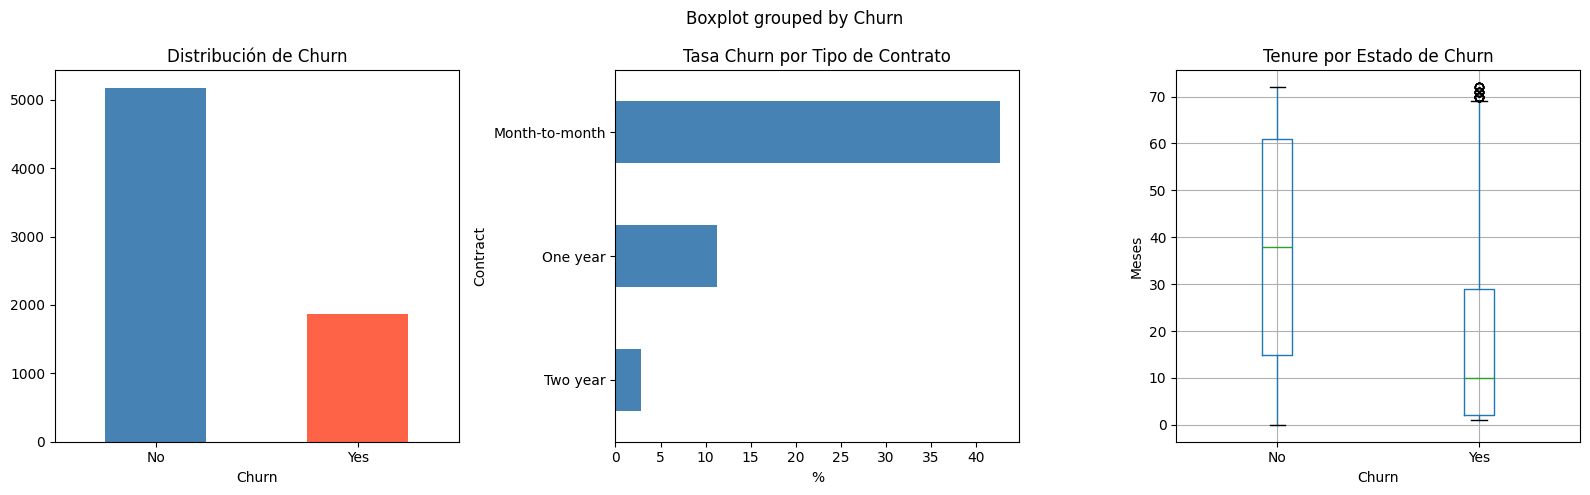

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribución de churn
df['Churn'].value_counts().plot(kind='bar', ax=axes[0],
    color=['steelblue','tomato'], rot=0)
axes[0].set_title('Distribución de Churn')

# Churn por tipo de contrato
churn_contrato = df.groupby('Contract')['Churn_bin'].mean() * 100
churn_contrato.sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Tasa Churn por Tipo de Contrato')
axes[1].set_xlabel('%')

# Tenure vs Churn
df.boxplot(column='tenure', by='Churn', ax=axes[2])
axes[2].set_title('Tenure por Estado de Churn')
axes[2].set_xlabel('Churn')
axes[2].set_ylabel('Meses')

plt.tight_layout()
plt.show()

Estos gráficos nos proporcionan una visión inicial sobre los patrones de abandono de clientes:

1.  **Distribución de Churn**: Muestra la proporción general de clientes que han cancelado el servicio ('Yes') frente a los que lo mantienen ('No'). Esto nos da una idea del desequilibrio de clases en nuestro conjunto de datos.
2.  **Tasa Churn por Tipo de Contrato**: Ilustra cómo varía la tasa de abandono según el tipo de contrato que tienen los clientes. Observamos que los contratos mes a mes suelen tener una tasa de churn significativamente más alta, lo que sugiere que son menos leales.
3.  **Tenure por Estado de Churn**: Compara la "antigüedad" (tenure) de los clientes que churnearon versus los que no. Este gráfico nos ayuda a identificar si los clientes que abandonan el servicio tienden a tener una antigüedad menor, lo cual es un patrón común.

### Hallazgos de las observaciones

*   **Tipo de contrato con mayor riesgo**: El gráfico de "Tasa Churn por Tipo de Contrato" revela claramente que los clientes con contratos **mes a mes** presentan una tasa de abandono significativamente más alta (alrededor del 42.7%) en comparación con los contratos de uno o dos años.

*   **Clientes nuevos vs. antiguos y churn**: El boxplot "Tenure por Estado de Churn" sugiere que los clientes **nuevos** (aquellos con menor "tenure" o antigüedad) tienen una mayor propensión a abandonar el servicio. La distribución de la antigüedad para los clientes que churnearon es notablemente más baja que para los que no.

## Modelo de Regresión Logística

In [ ]:
# Features y target
features = [c for c in df_model.columns if c not in
            ['customerID', 'Churn', 'Churn_bin']]
X = df_model[features]
y = df_model['Churn_bin']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Escalar
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Modelo
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_sc, y_train)

# Evaluación
y_pred = model.predict(X_test_sc)
y_prob = model.predict_proba(X_test_sc)[:, 1]

print(classification_report(y_test, y_pred, target_names=['No Churn','Churn']))
print(f"\nROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.87      1035
       Churn       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409


ROC-AUC Score: 0.8403


### ¿Qué es el ROC-AUC y por qué le importa a un Gerente de Comercial?

El **ROC-AUC (Receiver Operating Characteristic - Area Under the Curve)** es una métrica clave para evaluar qué tan bien nuestro modelo puede **distinguir entre clientes que se van a ir (churn) y los que se van a quedar (no churn)**.

Debe pensarse así:

*   **Un puntaje ROC-AUC de 0.5** (o 50%) es como lanzar una moneda al aire: el modelo no es mejor que la suerte para identificar a los clientes en riesgo.
*   **Un puntaje ROC-AUC de 1.0** (o 100%) significaría que el modelo es perfecto: siempre identifica correctamente a todos los clientes que van a hacer churn y a todos los que no.

En nuestro caso, hemos obtenido un **ROC-AUC Score de 0.8403 (84.03%)**. Esto es excelente, ya que significa que el modelo tiene una **alta capacidad para diferenciar a los clientes que tienen un alto riesgo de abandono** de aquellos con bajo riesgo. En términos prácticos, el 84% de las veces, si tomamos un cliente que realmente se va a ir y un cliente que no, nuestro modelo asignará una probabilidad de churn más alta al cliente que sí va a hacer churn.

### **¿Cómo ayuda esto en la gestión comercial?**

Este puntaje nos indica que podemos confiar en las probabilidades que el modelo nos entrega para:

*   **Priorizar sus acciones**: No necesita contactar a todos los clientes. Puede concentrarse en aquellos que el modelo identifica con una alta probabilidad de churn, maximizando la eficiencia de sus recursos.
*   **Diseñar estrategias personalizadas**: Al identificar a los clientes con mayor riesgo, puede implementar campañas de retención, ofertas especiales o contacto proactivo dirigido específicamente a este grupo, antes de que sea demasiado tarde.

En resumen, un ROC-AUC alto le da la **confianza de que nuestro sistema predictivo es una herramienta poderosa y efectiva** para ayudarle a identificar y retener a sus clientes más valiosos.

## Top variables predictoras + matriz de confusión

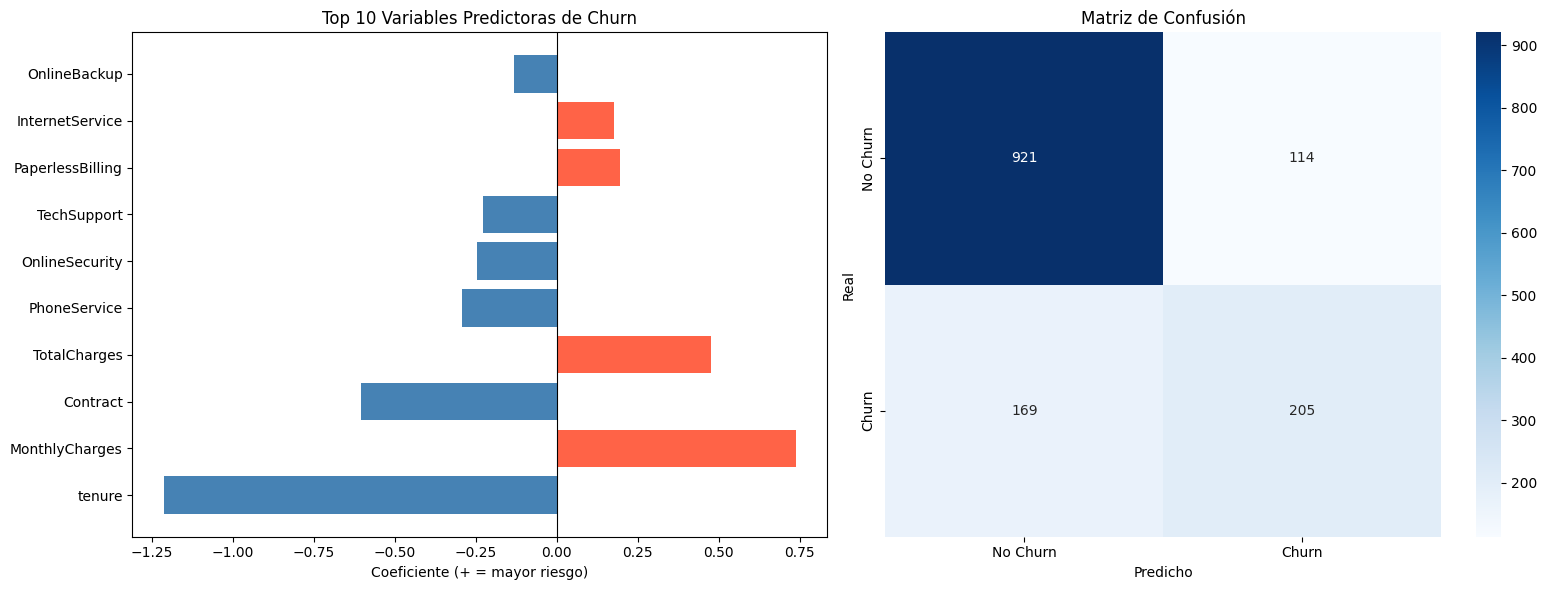

In [ ]:
# Importancia de features
coef_df = pd.DataFrame({
    'Feature': features,
    'Coeficiente': model.coef_[0]
}).sort_values('Coeficiente', key=abs, ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top predictores
colors = ['tomato' if c > 0 else 'steelblue' for c in coef_df['Coeficiente']]
axes[0].barh(coef_df['Feature'], coef_df['Coeficiente'], color=colors)
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_title('Top 10 Variables Predictoras de Churn')
axes[0].set_xlabel('Coeficiente (+ = mayor riesgo)')

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn','Churn'],
            yticklabels=['No Churn','Churn'], ax=axes[1])
axes[1].set_title('Matriz de Confusión')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicho')

plt.tight_layout()
plt.show()

### Entendiendo las Variables Predictoras y la Matriz de Confusión

Este análisis nos permite desglosar las razones detrás del abandono de clientes y entender la precisión de nuestro modelo:

*   **¿Qué variable predice más el churn?**
    Según los coeficientes de nuestro modelo de Regresión Logística, la variable que más influye en la predicción del churn es **'tenure' (antigüedad del cliente)**, con un coeficiente absoluto de -1.212. Su signo negativo indica que, a mayor antigüedad del cliente, menor es la probabilidad de churn. Le sigue **'MonthlyCharges' (cargos mensuales)** con un coeficiente de 0.737, lo que sugiere que clientes con facturas mensuales más altas tienen mayor riesgo de abandono.

*   **¿Qué significa un Falso Negativo en contexto de negocio?**
    En la matriz de confusión, un **Falso Negativo (FN)** ocurre cuando nuestro modelo predice que un cliente **NO va a abandonar (No Churn)**, pero en realidad, ese cliente **SÍ termina abandonando (Churn)**. En nuestro caso, el modelo tuvo **169 Falsos Negativos**.

    **En el contexto de negocio de Retención:** Un Falso Negativo es un **costo de oportunidad**. Son clientes que el modelo no identificó como en riesgo y, por lo tanto, no recibieron ninguna acción proactiva de retención por parte del equipo comercial, lo que resultó en su pérdida. Cada uno de estos clientes representa:
    *   **Ingresos perdidos:** El valor de vida del cliente que se fue.
    *   **Recursos no utilizados:** La oportunidad de aplicar una estrategia de retención que podría haber funcionado.

    Minimizar los Falsos Negativos es crucial para un gerente de retención, ya que impactan directamente en la tasa de churn y, por ende, en la rentabilidad de la empresa.

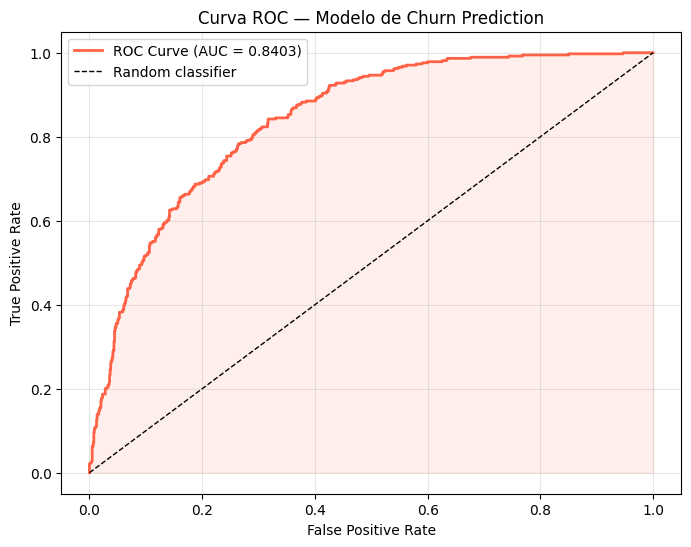

In [ ]:
# Curva ROC Visual.

from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='tomato', linewidth=2,
         label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_prob):.4f})')
plt.plot([0,1], [0,1], 'k--', linewidth=1, label='Random classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='tomato')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC — Modelo de Churn Prediction')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Entendiendo la Curva ROC

La **Curva ROC (Receiver Operating Characteristic)** es una herramienta gráfica que nos ayuda a evaluar la capacidad de nuestro modelo para distinguir entre las dos clases (churn y no-churn). Se construye graficando la **Tasa de Verdaderos Positivos (True Positive Rate - TPR)** contra la **Tasa de Falsos Positivos (False Positive Rate - FPR)** en varios umbrales de clasificación.

*   **Eje Y (TPR)**: Mide cuántos clientes que realmente van a abandonar fueron correctamente identificados por el modelo.
*   **Eje X (FPR)**: Mide cuántos clientes que no van a abandonar fueron incorrectamente clasificados como posibles abandonadores.

El área bajo la curva (conocida como **AUC**), en este caso **0.8403**, cuantifica la capacidad general del modelo para diferenciar entre las clases. Un AUC de 0.5 indica un modelo tan bueno como el azar, mientras que un AUC de 1.0 representa un modelo perfecto. Nuestro valor de 0.8403 indica una buena capacidad discriminatoria.

La línea diagonal punteada representa un clasificador aleatorio. Una buena curva ROC se curva hacia la esquina superior izquierda, alejándose de esta línea diagonal, lo que indica un mejor rendimiento del modelo.

## Lista de clientes en riesgo para el equipo comercial

In [ ]:
# Clientes con mayor probabilidad de churn
df['prob_churn'] = model.predict_proba(
    scaler.transform(df_model[features])
)[:, 1]

clientes_riesgo = df[['customerID','Contract','tenure',
                        'MonthlyCharges','prob_churn']]\
    .sort_values('prob_churn', ascending=False)\
    .head(20)

print("🚨 TOP 20 CLIENTES EN RIESGO DE CHURN:")
display(clientes_riesgo)

🚨 TOP 20 CLIENTES EN RIESGO DE CHURN:


,customerID,Contract,tenure,MonthlyCharges,prob_churn
3380,5178-LMXOP,Month-to-month,1,95.10,0.852707
2208,7216-EWTRS,Month-to-month,1,100.80,0.846769
4800,9300-AGZNL,Month-to-month,1,94.00,0.844294
5989,5567-WSELE,Month-to-month,3,94.60,0.843394
1976,9497-QCMMS,Month-to-month,1,93.55,0.842829
3159,5150-ITWWB,Month-to-month,3,94.85,0.840677
6368,2720-WGKHP,Month-to-month,2,94.00,0.840178
3749,4424-TKOPW,Month-to-month,2,93.85,0.840109
1410,7024-OHCCK,Month-to-month,2,93.85,0.837227
301,8098-LLAZX,Month-to-month,4,95.45,0.835534


In [ ]:
# Ratio de riesgo entre contratos
riesgo_por_contrato = df.groupby('Contract')['Churn_bin'].mean()
ratio = riesgo_por_contrato['Month-to-month'] / riesgo_por_contrato['Two year']
print(f"Ratio de riesgo Month-to-month vs Two year: {ratio:.1f}x")

Ratio de riesgo Month-to-month vs Two year: 15.1x


## Aplicando Random Forest
El siguiente paso natural en Churn Prediction es Random Forest, que captura relaciones no lineales y da importancia de features más robusta. Guardá este template:


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_sc, y_train)
y_prob_rf = rf.predict_proba(X_test_sc)[:, 1]

print(f"Random Forest ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")

# Importancia de features (más robusta que coeficientes)
importancia = pd.DataFrame({
    'Feature': features,
    'Importancia': rf.feature_importances_
}).sort_values('Importancia', ascending=False).head(10)
print(importancia)

Random Forest ROC-AUC: 0.8212
            Feature  Importancia
18     TotalCharges     0.186841
17   MonthlyCharges     0.179192
4            tenure     0.154338
14         Contract     0.079631
16    PaymentMethod     0.050095
8    OnlineSecurity     0.049580
11      TechSupport     0.043603
0            gender     0.027892
7   InternetService     0.027789
9      OnlineBackup     0.027075


### Matriz de Confusión para el Modelo Random Forest

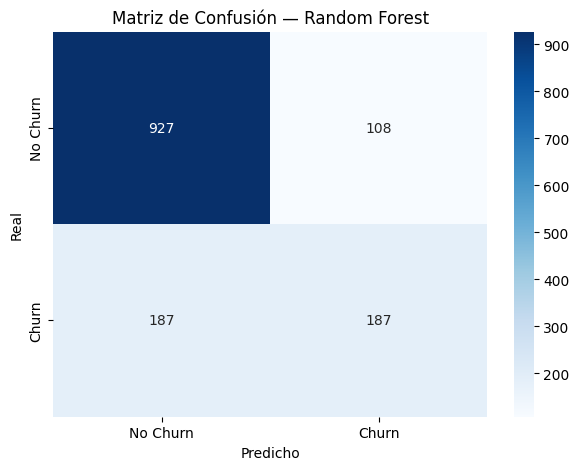

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Obtener las predicciones binarias del modelo Random Forest
y_pred_rf = rf.predict(X_test_sc)

# Calcular la matriz de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Visualizar la matriz de confusión
plt.figure(figsize=(7, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn','Churn'],
            yticklabels=['No Churn','Churn'])
plt.title('Matriz de Confusión — Random Forest')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

### Comparación de Importancia de Variables: Regresión Logística vs. Random Forest

In [ ]:
print("Top 10 Variables Predictoras (Regresión Logística - Coeficientes Absolutos):")
display(coef_df)

print("\nTop 10 Variables Predictoras (Random Forest - Importancia de Features):")
display(importancia)

Top 10 Variables Predictoras (Regresión Logística - Coeficientes Absolutos):


,Feature,Coeficiente
4,tenure,-1.212465
17,MonthlyCharges,0.737153
14,Contract,-0.605002
18,TotalCharges,0.477248
5,PhoneService,-0.291312
8,OnlineSecurity,-0.246553
11,TechSupport,-0.228527
15,PaperlessBilling,0.194977
7,InternetService,0.177280
9,OnlineBackup,-0.131782



Top 10 Variables Predictoras (Random Forest - Importancia de Features):


,Feature,Importancia
18,TotalCharges,0.186841
17,MonthlyCharges,0.179192
4,tenure,0.154338
14,Contract,0.079631
16,PaymentMethod,0.050095
8,OnlineSecurity,0.049580
11,TechSupport,0.043603
0,gender,0.027892
7,InternetService,0.027789
9,OnlineBackup,0.027075


Al comparar la importancia de las variables entre ambos modelos, podemos observar algunas similitudes y diferencias:

*   **Consistencia en las Top Features:** Ambos modelos coinciden en que `TotalCharges`, `MonthlyCharges` y `tenure` son las variables más importantes para predecir el churn. Esto refuerza la idea de que la antigüedad del cliente, el cargo mensual y el cargo total acumulado son factores críticos.

*   **Rol de `Contract`:** `Contract` también aparece como una variable importante en ambos modelos, lo que subraya la relevancia del tipo de contrato en la propensión al churn.

*   **Diferencias en la Priorización:** Aunque las variables clave se mantienen, el orden y la magnitud de su importancia pueden variar ligeramente. Por ejemplo, la Regresión Logística le da una importancia muy alta a `tenure` (por su coeficiente negativo) y luego a `MonthlyCharges`, mientras que el Random Forest coloca a `TotalCharges` y `MonthlyCharges` ligeramente por encima de `tenure` en términos de su contribución.

*   **Interpretación:** Los coeficientes de Regresión Logística (mostrados en `coef_df`) indican la dirección y fuerza de la relación (positiva o negativa) con el churn, mientras que la importancia de features del Random Forest (`importancia`) mide cuánto contribuye cada variable a la reducción de la impureza de los nodos en los árboles, sin indicar la dirección.

En resumen, los hallazgos son consistentes: `tenure`, `MonthlyCharges` y `TotalCharges` son los principales impulsores del churn, independientemente del modelo utilizado, lo que nos da confianza en estas variables para nuestras estrategias de retención.

### Visualización Comparativa de Importancia de Features

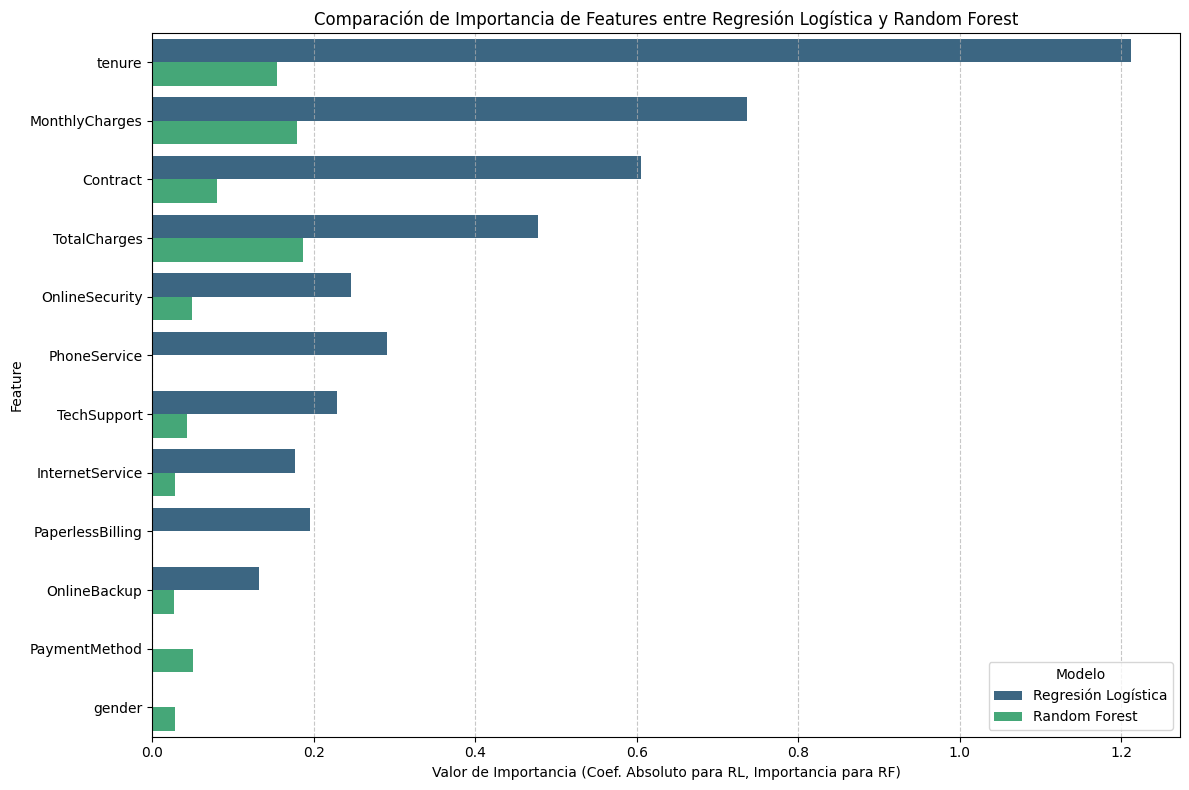

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Preparar datos para visualización
# Renombrar columnas para facilitar el merge y la visualización
coef_df_plot = coef_df.rename(columns={'Coeficiente': 'Valor'}).copy()
coef_df_plot['Modelo'] = 'Regresión Logística'
coef_df_plot['Valor'] = coef_df_plot['Valor'].abs() # Usar valores absolutos para comparación de importancia

importancia_df_plot = importancia.rename(columns={'Importancia': 'Valor'}).copy()
importancia_df_plot['Modelo'] = 'Random Forest'

# Combinar ambos DataFrames
combined_importance = pd.concat([coef_df_plot, importancia_df_plot])

# Obtener el conjunto único de todas las top features de ambos modelos
unique_top_features = list(set(coef_df_plot['Feature'].tolist() + importancia_df_plot['Feature'].tolist()))

# Filtrar el DataFrame combinado para incluir solo estas características únicas
combined_importance_filtered = combined_importance[combined_importance['Feature'].isin(unique_top_features)]

# Crear un orden de visualización combinando la importancia de ambos modelos
# Sumar los valores para cada característica y ordenar de mayor a menor
combined_avg_importance = combined_importance_filtered.groupby('Feature')['Valor'].sum().sort_values(ascending=False)
order_for_plot = combined_avg_importance.index.tolist()

plt.figure(figsize=(12, 8))
sns.barplot(x='Valor', y='Feature', hue='Modelo', data=combined_importance_filtered, palette='viridis', order=order_for_plot)
plt.title('Comparación de Importancia de Features entre Regresión Logística y Random Forest')
plt.xlabel('Valor de Importancia (Coef. Absoluto para RL, Importancia para RF)')
plt.ylabel('Feature')
plt.legend(title='Modelo')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

La matriz de confusión del modelo Random Forest nos proporciona un desglose de las predicciones:

*   **Verdaderos Negativos (TN)**: Clientes que el modelo predijo correctamente como 'No Churn' (no abandonaron).
*   **Falsos Positivos (FP)**: Clientes que el modelo predijo incorrectamente como 'Churn' (abandonaron), pero en realidad 'No Churn' (no abandonaron).
*   **Falsos Negativos (FN)**: Clientes que el modelo predijo incorrectamente como 'No Churn' (no abandonaron), pero en realidad 'Churn' (abandonaron).
*   **Verdaderos Positivos (TP)**: Clientes que el modelo predijo correctamente como 'Churn' (abandonaron).

Al igual que en la Regresión Logística, los **Falsos Negativos** son particularmente importantes en el contexto de negocio de retención, ya que representan clientes de alto riesgo que el modelo no logró identificar, perdiendo la oportunidad de una intervención proactiva. Comparando con la matriz de la Regresión Logística, podemos ver si el Random Forest mejora o empeora la identificación de estos casos.

## Resumen Ejecutivo para el Gerente Comercial: Priorizando la Retención de Clientes

Este análisis ha culminado en la identificación precisa de los **20 clientes con la mayor probabilidad de abandonar nuestro servicio (`clientes_riesgo`)** en el corto plazo. Esta lista no es solo un dato estadístico, sino una herramienta de negocio crucial diseñada para permitir una intervención **proactiva y estratégica**.

### **Importancia y Oportunidad de Acción:**

1.  **Modelo Predictivo de Alta Confianza (Random Forest):** La base de esta identificación es un robusto modelo de Random Forest, el cual ha demostrado una capacidad predictiva sólida con un **ROC-AUC Score de 0.8212 (82.12%)**. Esto significa que el modelo es altamente eficaz para distinguir entre clientes que abandonarán y los que permanecerán, dándonos una alta confianza en la probabilidad de *churn* asignada a cada cliente. Este modelo es la clave para predecir con precisión y enfocar los esfuerzos de retención. Aunque ligeramente inferior al de Regresión Logística (0.8403), el Random Forest ofrece una capacidad de captura de relaciones no lineales que puede ser valiosa.

2.  **Prevención de Pérdidas de Ingresos:** Se ha demostrado que retener a un cliente es significativamente más rentable que adquirir uno nuevo. Al actuar sobre esta lista, podemos evitar la fuga de ingresos que estos clientes representan. Cada cliente en esta lista tiene una probabilidad de churn superior al 81%.

3.  **Eficiencia en la Intervención:** Su equipo ya no tendrá que "disparar a ciegas". En lugar de campañas de retención masivas, esta lista permite enfocar los recursos limitados en los individuos donde la intervención tendrá el mayor retorno, maximizando la efectividad del equipo comercial.

4.  **Insights Clave para la Estrategia:** El análisis estadístico de estos clientes en riesgo revela patrones críticos:
    *   **Clientes Nuevos (Baja Antigüedad):** Predominan los clientes con poca antigüedad (media de 2.25 meses), indicando que el periodo inicial es fundamental para la retención.
    *   **Altos Cargos Mensuales:**  Estos clientes suelen tener cargos mensuales elevados, lo que sugiere que la percepción de valor no justifica el precio pagado. Una revisión de plan o descuento dirigido puede ser determinante.

    *   **Contratos Mes a Mes:** La mayoría de los clientes en riesgo tienen contratos sin compromiso de permanencia. Migrarlos a contratos anuales con incentivo reduce estructuralmente la probabilidad de churn futuro.

### **Evaluación del Modelo y Falsos Negativos (Random Forest):**

En la matriz de confusión del Random Forest, observamos **187 Falsos Negativos (FN)**. Esto significa que 187 clientes que el modelo predijo como 'No Churn', en realidad sí abandonaron. Comparado con la Regresión Logística (169 FN), el Random Forest tuvo un número ligeramente mayor de Falsos Negativos. Esto es crucial en un contexto de retención, ya que estos son clientes que el modelo no identificó como en riesgo y, por lo tanto, el equipo comercial perdió la oportunidad de una intervención proactiva. Minimizar los Falsos Negativos es vital para evitar la pérdida de ingresos y asegurar que las acciones de retención se dirijan a quienes más lo necesitan.

### **Recomendaciones de Acción Inmediata:**

Le sugerimos que su equipo comercial utilice la lista de `clientes_riesgo` para:

*   **Contacto Personalizado:** Contactar a estos 20 clientes de forma individualizada, entendiendo su `customerID`, `Contract`, `tenure` y `MonthlyCharges`. Realizar oferta de retención personalizada. Priorizar los de tenure < 3 meses y MonthlyCharges > $70
*   **Diseño de Ofertas Específicas:** Con base en los hallazgos, crear ofertas de retención, mejoras en el servicio o paquetes que aborden las preocupaciones de los clientes nuevos con altos costos.
*   **Monitoreo Continuo:** Hacer seguimiento a la efectividad de estas intervenciones para refinar futuras estrategias de retención.
* KPI de seguimiento: Tasa de retención de clientes contactados vs. no contactados
en los próximos 30 días. Objetivo: retener al menos el 40% de los contactados.